### Escuela Politécnica Nacional ###

**Nombre:** Kevin Eduardo Garcia Rodriguez

**Tema:** [Taller 6] Gauss Jordan VS Eliminacion Gausiana

**Repositorio GIT:** https://github.com/Nattyrd/Metodos-Numericos-2025B

### EJERCICO 1-Complejidad entre Gauss VS Gauss-Jordan

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def graficar_complejidad_gauss(n_max=100):
    """
    Grafica la complejidad computacional de:
    - Eliminación Gaussiana
    - Gauss-Jordan
    
    Parámetros:
    n_max (int): tamaño máximo del sistema (por defecto 100)
    """
    n = np.arange(1, n_max + 1)

    # Complejidades aproximadas
    gauss = n**3/3+n**2/2-5*n/6          # Eliminación Gaussiana
    gauss_jordan = n**3 /2-n/2        # Gauss-Jordan

    plt.figure()
    plt.plot(n, gauss, label="Eliminación Gaussiana")
    plt.plot(n, gauss_jordan, label="Gauss-Jordan")
    plt.xlabel("Tamaño del sistema (n)")
    plt.ylabel("Número de operaciones aproximadas")
    plt.title("Crecimiento de la complejidad computacional")
    plt.legend()
    plt.grid(True)
    plt.show()


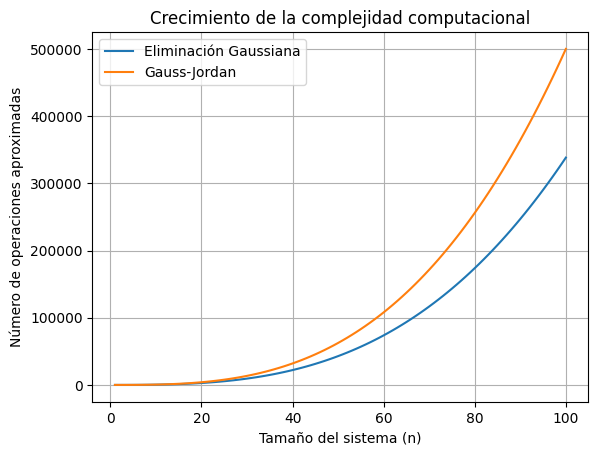

In [14]:
graficar_complejidad_gauss(n_max=100)


In [12]:
import matplotlib.pyplot as plt
import numpy as np



def graficar_complejidad_gauss_Multiplicaciones(n_max=100):
    """
    Grafica la complejidad computacional de:
    - Eliminación Gaussiana
    - Gauss-Jordan

    Parámetros:
    n_max (int): tamaño máximo del sistema (por defecto 100)
    """
    n = np.arange(1, n_max + 1)

    # Complejidades aproximadas
    gauss = n**3 / 3 + n**2 / 2 - 5 * n / 6      # Eliminación Gaussiana
    gauss_jordan = n**3 / 2 - n / 2              # Gauss-Jordan

    plt.figure()
    plt.plot(n, gauss, label="Eliminación Gaussiana")
    plt.plot(n, gauss_jordan, label="Gauss-Jordan")
    plt.xlabel("Tamaño del sistema (n)")
    plt.ylabel("Número de operaciones aproximadas")
    plt.title("Crecimiento de la complejidad computacional")
    plt.legend()
    plt.grid(True)
    plt.show()


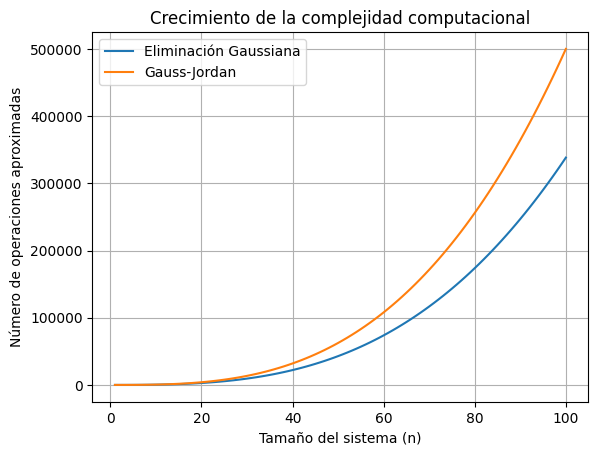

In [13]:
graficar_complejidad_gauss_Multiplicaciones(n_max=100)

### EJERCICIO 2

### Resuelva el bug encontrado en el código
Solucion dada por el mal uso de INT, obligamos que trabaje con FLOAT

In [1]:
# -*- coding: utf-8 -*-
"""
Python 3
05 / 07 / 2024
@author: z_tjona

"I find that I don't understand things unless I try to program them."
-Donald E. Knuth
"""

# ----------------------------- logging --------------------------
import logging
from sys import stdout
from datetime import datetime

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(levelname)s] %(message)s",
    stream=stdout,
    datefmt="%m-%d %H:%M:%S",
)
logging.info(datetime.now())

import numpy as np


# ####################################################################
def eliminacion_gaussiana(A: np.ndarray | list[list[float | int]]) -> np.ndarray:
    """Resuelve un sistema de ecuaciones lineales mediante el método de eliminación gaussiana.

    ## Parameters

    ``A``: matriz aumentada del sistema de ecuaciones lineales. Debe ser de tamaño n-by-(n+1), donde n es el número de incógnitas.

    ## Return

    ``solucion``: vector con la solución del sistema de ecuaciones lineales.

    """
    if not isinstance(A, np.ndarray):
        logging.debug("Convirtiendo A a numpy array.")
        A = np.array(A, dtype=float) # Arreglo para reducir el error
    assert A.shape[0] == A.shape[1] - 1, "La matriz A debe ser de tamaño n-by-(n+1)."
    n = A.shape[0]

    for i in range(0, n - 1):  # loop por columna

        # --- encontrar pivote
        p = None  # default, first element
        for pi in range(i, n):
            if A[pi, i] == 0:
                # must be nonzero
                continue

            if p is None:
                # first nonzero element
                p = pi
                continue

            if abs(A[pi, i]) < abs(A[p, i]):
                p = pi

        if p is None:
            # no pivot found.
            raise ValueError("No existe solución única.")

        if p != i:
            # swap rows
            logging.debug(f"Intercambiando filas {i} y {p}")
            _aux = A[i, :].copy()
            A[i, :] = A[p, :].copy()
            A[p, :] = _aux

        # --- Eliminación: loop por fila
        for j in range(i + 1, n):
            m = A[j, i] / A[i, i]
            A[j, i:] = A[j, i:] - m * A[i, i:]

        logging.info(f"\n{A}")

    if A[n - 1, n - 1] == 0:
        raise ValueError("No existe solución única.")

        print(f"\n{A}")
    # --- Sustitución hacia atrás
    solucion = np.zeros(n)
    solucion[n - 1] = A[n - 1, n] / A[n - 1, n - 1]

    for i in range(n - 2, -1, -1):
        suma = 0
        for j in range(i + 1, n):
            suma += A[i, j] * solucion[j]
        solucion[i] = (A[i, n] - suma) / A[i, i]

    return solucion



[12-25 16:20:04][INFO] 2025-12-25 16:20:04.392345


In [2]:

Ab = [[4, 1, 2, 9], [2, 4, -1, -5], [1, 1, -3, -9]]

eliminacion_gaussiana(Ab)

[12-25 16:20:08][INFO] 
[[ 1.  1. -3. -9.]
 [ 0.  2.  5. 13.]
 [ 0. -3. 14. 45.]]
[12-25 16:20:08][INFO] 
[[ 1.   1.  -3.  -9. ]
 [ 0.   2.   5.  13. ]
 [ 0.   0.  21.5 64.5]]


array([ 1., -1.,  3.])

### Ejercicio 3-Implemente el conteo de sumas, restas, multiplicacíones y divisiones junto a los intercambios de filaspara ambos metodos

In [14]:
import numpy as np
import logging

def eliminacion_gaussiana_contada(A):
    if not isinstance(A, np.ndarray):
        A = np.array(A, dtype=float)

    assert A.shape[0] == A.shape[1] - 1
    n = A.shape[0]

    # Contadores
    sumas = 0
    mult_div = 0
    swaps = 0

    # Eliminación
    for i in range(0, n - 1):

        # --- pivoteo
        p = None
        for pi in range(i, n):
            if A[pi, i] == 0:
                continue
            if p is None or abs(A[pi, i]) < abs(A[p, i]):
                p = pi

        if p is None:
            raise ValueError("No existe solución única.")

        if p != i:
            A[[i, p], :] = A[[p, i], :]
            swaps += 1

        # --- Eliminación hacia adelante
        for j in range(i + 1, n):
            m = A[j, i] / A[i, i]
            mult_div += 1  # división

            for k in range(i, n + 1):
                A[j, k] = A[j, k] - m * A[i, k]
                mult_div += 1  # multiplicación
                sumas += 1     # resta

    # Sustitución hacia atrás
    solucion = np.zeros(n)
    solucion[n - 1] = A[n - 1, n] / A[n - 1, n - 1]
    mult_div += 1

    for i in range(n - 2, -1, -1):
        suma = 0
        for j in range(i + 1, n):
            suma += A[i, j] * solucion[j]
            mult_div += 1
            sumas += 1
        solucion[i] = (A[i, n] - suma) / A[i, i]
        sumas += 1
        mult_div += 1

    return solucion, sumas, mult_div, swaps




In [15]:
def gauss_jordan_contado(A):
    if not isinstance(A, np.ndarray):
        A = np.array(A, dtype=float)

    assert A.shape[0] == A.shape[1] - 1
    n = A.shape[0]

    sumas = 0
    mult_div = 0
    swaps = 0

    for i in range(n):

        # --- pivoteo
        p = None
        for pi in range(i, n):
            if A[pi, i] != 0:
                p = pi
                break

        if p is None:
            raise ValueError("No existe solución única.")

        if p != i:
            A[[i, p], :] = A[[p, i], :]
            swaps += 1

        # --- Normalizar fila pivote
        pivote = A[i, i]
        for k in range(i, n + 1):
            A[i, k] /= pivote
            mult_div += 1

        # --- Eliminación completa
        for j in range(n):
            if j != i:
                m = A[j, i]
                for k in range(i, n + 1):
                    A[j, k] -= m * A[i, k]
                    mult_div += 1
                    sumas += 1

    solucion = A[:, n]
    return solucion, sumas, mult_div, swaps


In [18]:

def sistema_prueba(n):
    A = np.random.rand(n, n)
    b = np.random.rand(n, 1)
    return np.hstack([A, b])


# ============================================================
# Experimento y verificación de complejidad
# ============================================================

sizes = [5, 10, 20, 40]

print(" n | Gauss mult/div | Gauss sumas | swaps | GJ mult/div | GJ sumas | swaps")
print("-" * 80)

for n in sizes:
    A = sistema_prueba(n)

    _, s_g, m_g, sw_g = eliminacion_gaussiana_contada(A.copy())
    _, s_gj, m_gj, sw_gj = gauss_jordan_contado(A.copy())

    print(f"{n:2d} | {m_g:14d} | {s_g:11d} | {sw_g:5d} | "
          f"{m_gj:12d} | {s_gj:9d} | {sw_gj:5d}")

# ============================================================
# Verificación del orden cúbico
# ============================================================

print("\nVerificación de complejidad cúbica")
print(" n | Gauss m/n^3 | GJ m/n^3")
print("-" * 40)

for n in sizes:
    A = sistema_prueba(n)

    _, _, m_g, _ = eliminacion_gaussiana_contada(A.copy())
    _, _, m_gj, _ = gauss_jordan_contado(A.copy())

    print(f"{n:2d} | {m_g/n**3:10.4f} | {m_gj/n**3:10.4f}")



 n | Gauss mult/div | Gauss sumas | swaps | GJ mult/div | GJ sumas | swaps
--------------------------------------------------------------------------------
 5 |             75 |          64 |     3 |          100 |        80 |     0
10 |            475 |         429 |     6 |          650 |       585 |     0
20 |           3250 |        3059 |    17 |         4600 |      4370 |     0
40 |          23700 |       22919 |    37 |        34400 |     33540 |     0

Verificación de complejidad cúbica
 n | Gauss m/n^3 | GJ m/n^3
----------------------------------------
 5 |     0.6000 |     0.8000
10 |     0.4750 |     0.6500
20 |     0.4062 |     0.5750
40 |     0.3703 |     0.5375


### Imprime el nombre de cada columna:

n → tamaño del sistema

Gauss mult/div → multiplicaciones y divisiones en eliminación gaussiana

Gauss sumas → sumas y restas en eliminación gaussiana

swaps → intercambios de fila

GJ mult/div → multiplicaciones y divisiones en Gauss–Jordan

GJ sumas → sumas y restas en Gauss–Jordan

swaps → intercambios de fila en Gauss–Jordan

